# 8.1 序列模型

序列数据的当前观测通常与历史观测相关。时间序列预测可以把前 `tau` 个时间步作为特征，用来预测下一个时间步。


In [1]:
import torch
from torch import nn
from d2l import torch as d2l


## 生成一段带噪声的正弦序列


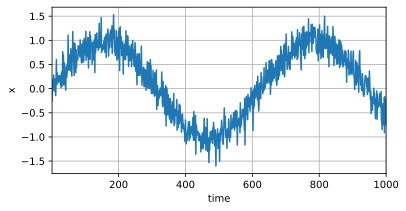

In [2]:
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))

d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))


## 构造特征和标签

使用前 `tau=4` 个观测预测下一个观测。


In [3]:
tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i:T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)


## 定义一个小型多层感知机


In [4]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)


def get_net():
    net = nn.Sequential(nn.Linear(4, 10), nn.ReLU(), nn.Linear(10, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')


## 训练模型


In [5]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01)


epoch 1, loss: 0.066232
epoch 2, loss: 0.060750
epoch 3, loss: 0.056777
epoch 4, loss: 0.055581
epoch 5, loss: 0.053699


d:\anaconda\Lib\site-packages\d2l\torch.py:3179: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


## 单步预测和多步预测

单步预测每次都使用真实历史；多步预测会把模型自己的预测继续喂回去，因此误差更容易累积。


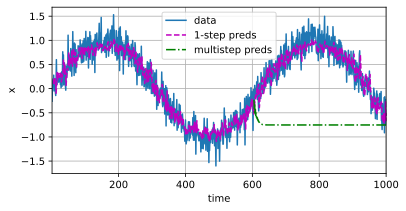

In [6]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]], [x.detach().numpy(), onestep_preds.detach().numpy()],
         'time', 'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))

multistep_preds = torch.zeros(T)
multistep_preds[:n_train + tau] = x[:n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(multistep_preds[i - tau:i].reshape((1, -1)))

d2l.plot([time, time[tau:], time[n_train + tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy(), multistep_preds[n_train + tau:].detach().numpy()],
         'time', 'x', legend=['data', '1-step preds', 'multistep preds'], xlim=[1, 1000], figsize=(6, 3))
